In [7]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [2]:
# ============================================================
# LOAD DATASETS
# ============================================================

merged_df = pd.read_csv('../data/MasterABT.csv')
print(merged_df.shape)

(425, 42)


<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      425 non-null    str    
 1   country                   425 non-null    str    
 2   local                     425 non-null    str    
 3   industry_sector           425 non-null    str    
 4   accident_level            425 non-null    str    
 5   potential_accident_level  425 non-null    str    
 6   gender                    425 non-null    str    
 7   employee_type             425 non-null    str    
 8   critical_risk             425 non-null    str    
 9   description               425 non-null    str    
 10  year                      425 non-null    int64  
 11  month                     425 non-null    int64  
 12  day                       425 non-null    int64  
 13  weekday                   425 non-null    str    
 14  weekofyear           

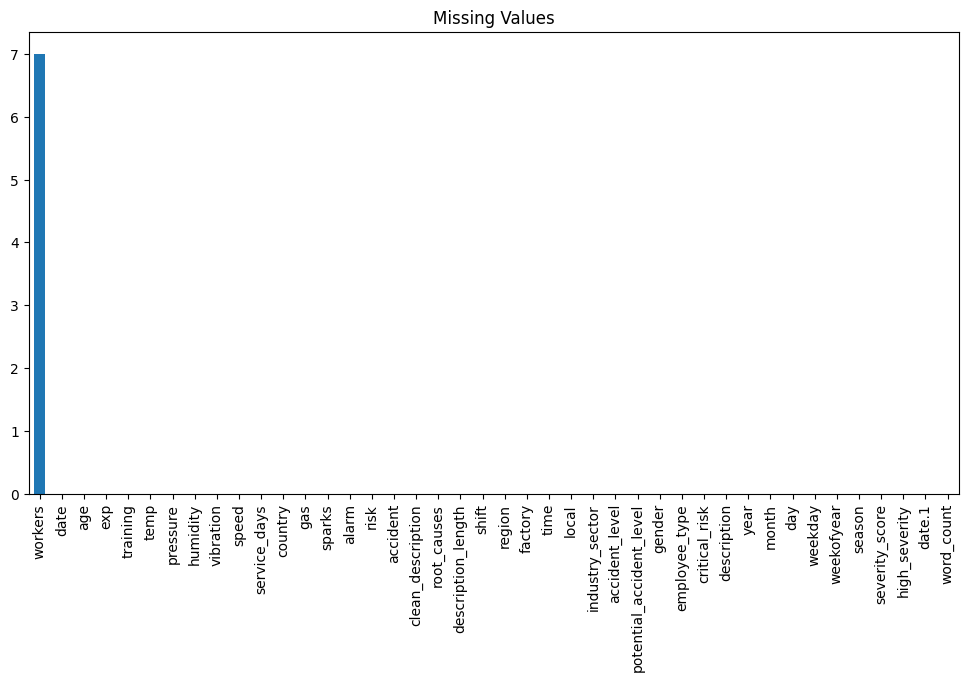

In [3]:
# ============================================================
# EDA
# ============================================================

print(merged_df.info())
print(merged_df.describe(include='all'))

# Missing Values
plt.figure(figsize=(12,6))
merged_df.isnull().sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Missing Values')
plt.show()

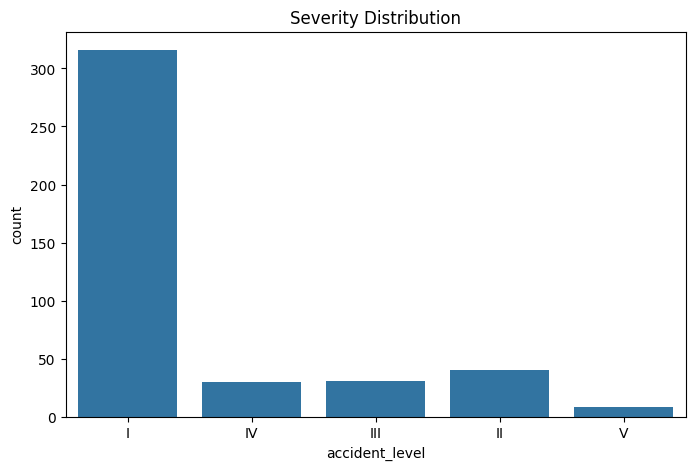

In [4]:
# Severity Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=merged_df, x='accident_level')
plt.title('Severity Distribution')
plt.show()

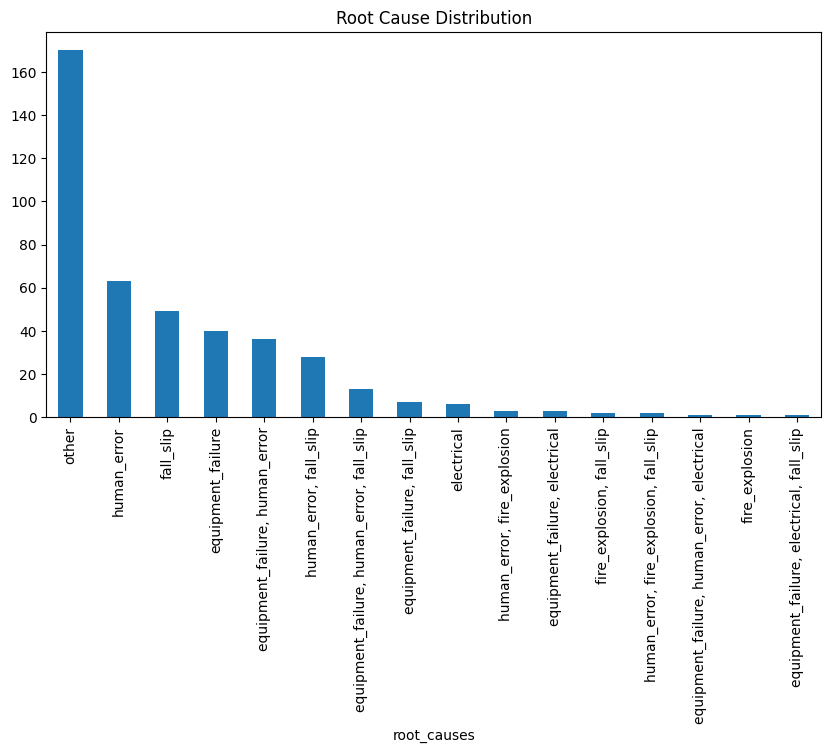

In [5]:
# Root Cause Distribution
plt.figure(figsize=(10,5))
merged_df['root_causes'].value_counts().plot(kind='bar')
plt.title('Root Cause Distribution')
plt.show()

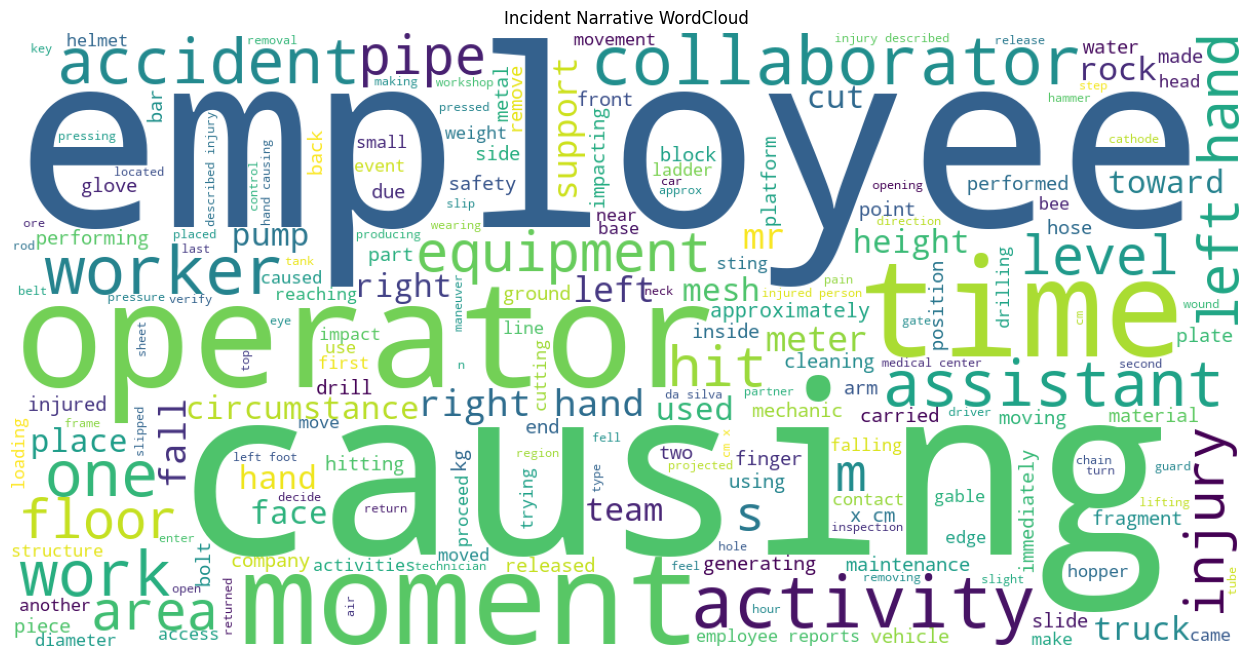

In [8]:
# Word Cloud
text = ' '.join(merged_df['clean_description'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(16,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Incident Narrative WordCloud')
plt.show()


['year', 'month', 'day', 'weekofyear', 'severity_score', 'high_severity', 'workers', 'temp', 'pressure', 'humidity', 'vibration', 'speed', 'age', 'service_days', 'gas', 'sparks', 'risk', 'accident', 'description_length', 'word_count']


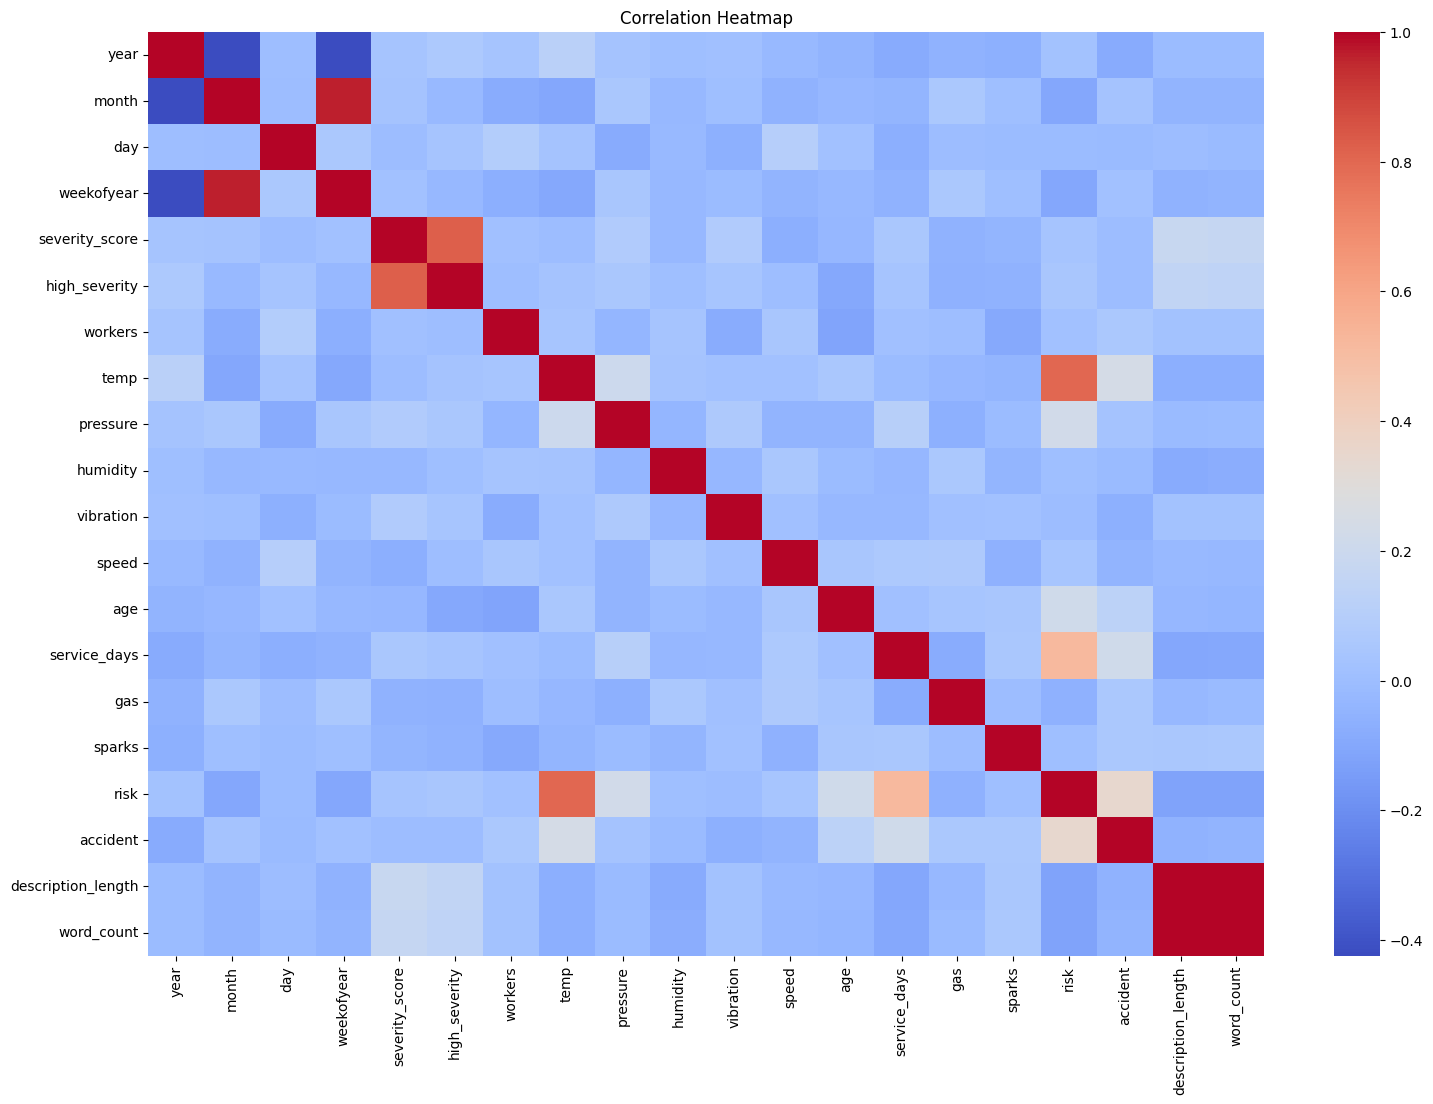

In [9]:
# ============================================================
# IDENTIFY NUMERIC COLUMNS
# ============================================================

numeric_cols = merged_df.select_dtypes(include=np.number).columns.tolist()

print(numeric_cols)

# Correlation Heatmap
plt.figure(figsize=(18,12))

sns.heatmap(
    merged_df[numeric_cols].corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()